# k-Nearest Neighbour (k-NN)

**Name:** Abdulaziz Aloufi  
**Student ID:** C00266252  
**Module:** Data Science & Machine Learning 2  

## Overview
This notebook implements the k-Nearest Neighbour (k-NN) algorithm using a dataset about the impact of AI on student performance.

The aim here is to predict the student's **performance category** (`Low`, `Medium`, `High`) based on AI usage and academic-related features.

In this notebook I will:
- load and inspect the dataset
- prepare the data
- encode categorical columns
- scale the features
- train a k-NN classifier
- test different values of `k`
- evaluate the results


In [1]:
# =====================================================
# k-Nearest Neighbour (k-NN)
# Name: Abdulaziz Aloufi
# Student ID: C00266252
# =====================================================

# importing the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# just setting a nicer style for the plots
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## 1. Load the dataset

For this notebook I am using a dataset about AI and student performance.

I chose this dataset because:
- it is different from the semester 1 dataset
- it matches the semester 2 portfolio better
- it has a good mix of AI-related and academic features
- it has a clear target column called `performance_category`

In [2]:
# loading the dataset
df = pd.read_csv("../data/ai_impact_student_performance_dataset.csv")

# first look at the data
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [3]:
# checking shape
print("Dataset shape:", df.shape)

# checking columns
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8000, 26)

Columns:
['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score', 'final_score', 'passed', 'performance_category']


In [4]:
# filling missing values in categorical columns with "Unknown"
df["ai_tools_used"] = df["ai_tools_used"].fillna("Unknown")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("Unknown")

# checking again
print(df.isnull().sum())
print("\nTotal missing values after fixing:", df.isnull().sum().sum())

student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

Total missing values aft

performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64


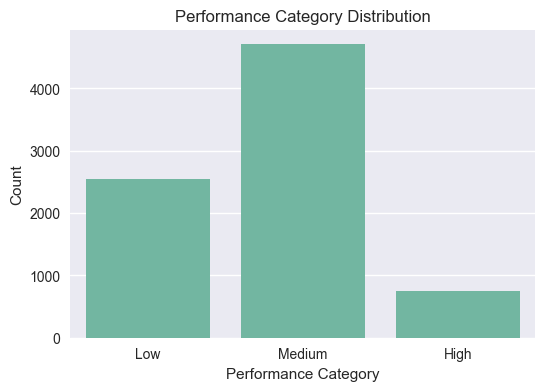

In [5]:
# seeing how many examples are in each performance category
print(df["performance_category"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="performance_category", data=df)
plt.title("Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Count")
plt.show()

In [6]:
# removing columns I don't want to use as features
X = df.drop(columns=["student_id", "final_score", "passed", "performance_category"])
y = df["performance_category"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8000, 22)
Target shape: (8000,)


In [7]:
# making a copy so I keep the original data safe
X_encoded = X.copy()

# finding categorical columns
cat_cols = X_encoded.select_dtypes(include=["object"]).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']


In [8]:
# encoding the categorical columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# encoding the target labels too
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# first look at encoded features
X_encoded.head()

,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
0,20,0,3,2.5,1,170,5,2,10,29,...,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6
1,17,1,2,3.4,1,123,5,4,4,14,...,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6
2,24,1,5,0.8,0,35,3,1,8,82,...,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3
3,21,0,2,4.4,0,45,1,4,3,74,...,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2
4,18,2,5,3.5,1,21,1,0,2,83,...,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2


In [9]:
# splitting into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (6400, 22)
Test shape: (1600, 22)


In [10]:
# scaling is important for k-NN because it uses distance
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (6400, 22)
Scaled test shape: (1600, 22)


In [11]:
# starting with k = 5
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Accuracy (k=5):", accuracy_score(y_test, y_pred))

Accuracy (k=5): 0.703125


In [12]:
# more detailed evaluation
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

        High       0.53      0.21      0.30       151
         Low       0.71      0.60      0.65       508
      Medium       0.71      0.84      0.77       941

    accuracy                           0.70      1600
   macro avg       0.65      0.55      0.57      1600
weighted avg       0.69      0.70      0.69      1600



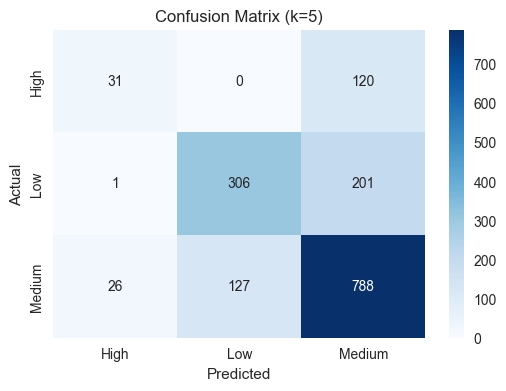

In [13]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix (k=5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
# trying different values of k
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

results_df = pd.DataFrame({
    "k": k_values,
    "accuracy": accuracies
})

results_df

,k,accuracy
0,1,0.638125
1,2,0.598125
2,3,0.679375
3,4,0.703125
4,5,0.703125
5,6,0.731875
6,7,0.727500
7,8,0.737500
8,9,0.730000
9,10,0.745000


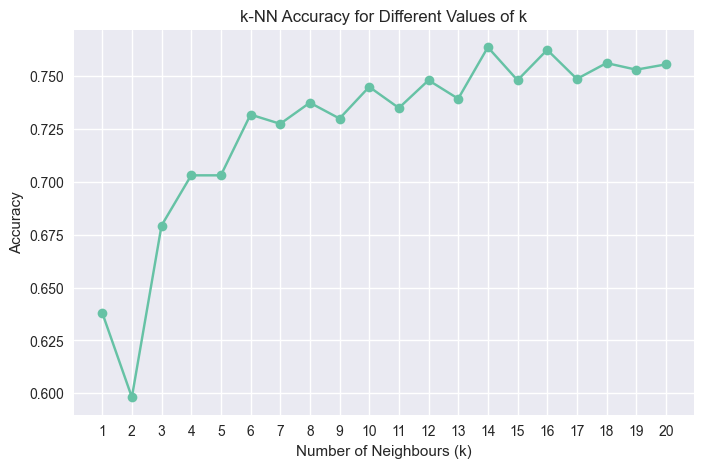

In [15]:
# plotting the results
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("k-NN Accuracy for Different Values of k")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [16]:
# finding the best k
best_k = results_df.loc[results_df["accuracy"].idxmax(), "k"]
print("Best k:", best_k)

# training the final model
final_knn = KNeighborsClassifier(n_neighbors=int(best_k))
final_knn.fit(X_train_scaled, y_train)

final_preds = final_knn.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, final_preds))

Best k: 14
Final Accuracy: 0.76375


In [17]:
print(classification_report(y_test, final_preds, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

        High       0.92      0.16      0.27       151
         Low       0.81      0.66      0.73       508
      Medium       0.74      0.92      0.82       941

    accuracy                           0.76      1600
   macro avg       0.83      0.58      0.61      1600
weighted avg       0.78      0.76      0.74      1600



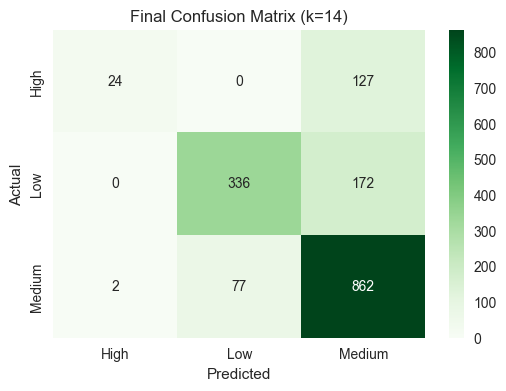

In [18]:
final_cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title(f"Final Confusion Matrix (k={int(best_k)})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10. Conclusion

In this notebook I implemented the k-Nearest Neighbour (k-NN) algorithm using a dataset about AI and student performance.

### Summary of work completed
- loaded and explored the dataset
- checked the dataset structure and missing values
- filled missing values in categorical columns using `"Unknown"`
- selected `performance_category` as the target variable
- removed columns such as `student_id`, `final_score`, and `passed`
- encoded categorical columns using `LabelEncoder`
- split the data into training and test sets
- scaled the features using `StandardScaler`
- trained an initial k-NN classifier
- evaluated the model using accuracy, classification report, and confusion matrices
- tested multiple values of `k`
- selected the best-performing value of `k`

### Results
The first model with `k = 5` achieved an accuracy of **0.7031**.

After testing different values of `k`, the best result was found at **k = 14**, which achieved a final accuracy of **0.7638**.

The model performed best on the **Medium** category, followed by **Low**, while the **High** category was the hardest to classify correctly. This is likely because the dataset is imbalanced, with far fewer `High` examples than `Medium` and `Low`.

### Reflection
This notebook showed that k-NN can be used to classify student performance categories based on AI usage and academic-related features. It also showed that feature scaling is very important for distance-based algorithms and that choosing the right value of `k` can improve performance noticeably.
